In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [7]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [8]:
X_train['Age'].isnull().sum()

np.int64(148)

In [9]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([34.5 , 40.5 , 29.  , 71.  , 31.  , 18.  , 18.  , 29.  , 28.  ,
       62.  , 22.  , 62.  , 38.  , 14.5 , 47.  ,  3.  , 36.  , 44.  ,
       47.  , 22.  , 35.  , 24.  , 19.  , 20.  , 29.  , 24.  , 30.  ,
       36.  , 34.  , 70.5 , 47.  , 19.  , 32.  , 23.  , 54.  , 58.  ,
       36.  , 30.  , 35.  , 39.  , 43.  , 23.  ,  9.  , 40.  ,  2.  ,
       25.  , 50.  , 17.  , 22.  , 22.  , 37.  , 16.  , 31.  , 22.  ,
       47.  , 26.  , 25.  , 46.  , 40.  , 42.  , 21.  , 25.  ,  2.  ,
       20.  , 29.  , 50.  ,  3.  , 25.  , 19.  ,  2.  , 45.  , 30.  ,
       36.  , 36.  , 40.  , 24.  , 13.  , 42.  , 20.  ,  0.67, 28.  ,
       17.  , 25.  , 18.  , 28.  , 50.  , 39.  , 26.  , 60.  , 30.  ,
       40.  , 18.  , 21.  , 41.  , 32.  , 36.5 , 32.  , 32.  ,  4.  ,
       32.  , 25.  , 26.  , 24.  , 51.  , 26.  , 27.  , 31.  , 28.  ,
       40.  , 37.  , 29.  , 33.  , 65.  ,  0.75, 18.  , 23.  , 31.  ,
       45.  , 18.  , 22.  , 30.  , 21.  , 30.  , 33.  , 45.  , 32.  ,
       35.  , 35.  ,

In [10]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_7337/3090101260.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_7337/3090101260.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are settin

In [11]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


/tmp/ipykernel_7337/2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
/tmp/ipykernel_7337/2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)


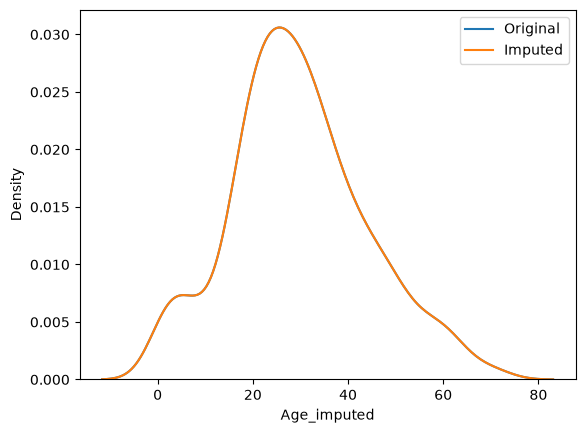

In [12]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [13]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  204.34951339046142


In [14]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,71.512440
Age,71.512440,204.349513,204.349513
Age_imputed,71.512440,204.349513,204.349513


<Axes: >

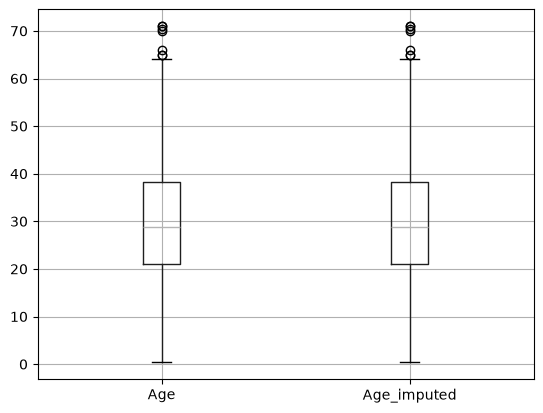

In [15]:
X_train[['Age', 'Age_imputed']].boxplot()

# If you wanna fix random value for particular input features during production(deployment):

In [17]:
for index, observation in X_train[X_train['Age'].isnull()].iterrows():

    sampled_value = X_train['Age'].dropna().sample(
        1,
        random_state=int(observation['Fare'])
    )

    X_train.loc[index, 'Age'] = sampled_value.iloc[0]

In [23]:
sampled_value

294    24.0
Name: Age, dtype: float64

# Running imputation twice:

In [24]:
X_train1 = X_train.copy()

for index, observation in X_train1[X_train1['Age'].isnull()].iterrows():
    sampled_value = X_train1['Age'].dropna().sample(
        1,
        random_state=int(observation['Fare'])
    )
    X_train1.loc[index, 'Age'] = sampled_value.iloc[0]

In [25]:
X_train2 = X_train.copy()

for index, observation in X_train2[X_train2['Age'].isnull()].iterrows():
    sampled_value = X_train2['Age'].dropna().sample(
        1,
        random_state=int(observation['Fare'])
    )
    X_train2.loc[index, 'Age'] = sampled_value.iloc[0]

In [ ]:
(X_train1['Age'] == X_train2['Age']).all()
# That proves every missing value received the same sampled age in both runs

np.True_

# Method 2: Check one passenger

In [27]:
Fare = 71.83